# Stablecoin-Depeg — a quantitative teardown 🔬
### Event study · cumulative abnormal return · synthetic control · the n = 2 wall · one-lag tradable rule · synthetic positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Depeg_%3D_sell_signal%3F: Busted](https://img.shields.io/badge/Depeg_%3D_sell_signal%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error (where one even exists).* We run an event study on a BTC+ETH basket around the two market-wide stablecoin depegs, benchmark the cumulative abnormal return against a synthetic-control null, and confront the inference floor: **n = 2.**

> ⚠️ **Not investment advice.** Real data: Yahoo BTC-USD / ETH-USD daily, equal-weight; as-of 2026-05-31 (in-progress month dropped); the offline core and tests run on a deterministic synthetic tape. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from stablecoin_depeg import data, strategy as st

PRE, POST = 5, 10
EVENTS = data.depeg_events(major_only=True)
HAVE_REAL = data.have_real_cache()

def basket():
    b = data.real_basket()
    return b[b.index <= pd.Timestamp("2026-05-31")]   # drop the in-progress month

print("real BTC/ETH cache present:", HAVE_REAL)


real BTC/ETH cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | UST CAR -15.4%, USDC CAR +32.9% (opposite signs); mean +8.7% (wrong sign), synthetic-control p = **0.78**; n = 2 ⇒ HAC *t* **undefined**. |
| **Tradability** | `MIRAGE` | 'sell on depeg' trails B&H by -5.1% gross (misses the USDC rebound); worse with costs. |
| **Depeg = sell signal?** | `BUSTED` | reaction sign is set by the *cause* (endogenous UST crash vs exogenous USDC/SVB rally), not by the depeg itself. |

> 💡 In plain words: the thesis survives only on a sample of one (UST). The second real data point flips its sign, the synthetic control says neither window is unusual, and two observations can't certify anything regardless.

## 1 · The claim, steelmanned

Let the basket's cumulative abnormal return over the window $[-5,+10]$ around depeg $i$ be $\mathrm{CAR}_i$ (abnormal = relative to the basket's own mean daily return outside event windows — the constant-mean event-study benchmark; crypto has no clean factor model). The believers' hypotheses:

- **H₁ (sell signal).** $\mathbb{E}[\mathrm{CAR}_i] < 0$ — depegs are followed by abnormal *losses*.
- **H₂ (unusual).** The depeg windows sit in the left tail of the distribution of random non-event windows.
- **H₃ (tradable).** Exiting after a depeg beats buy-and-hold, net of costs.

We find **H₁ rejected** (mean CAR is *positive*; the two events disagree on sign), **H₂ rejected** (p = 0.78), and **H₃ rejected** (-5.1% vs B&H). The binding meta-constraint is **n = 2**: no robust statistic is definable.

## 2 · So what? — what rides on each answer

A dated, public, parameter-free trigger would be a rare prize in crypto. But the quantitative stakes here are mostly *negative knowledge*: demonstrating that a salient event type carries **no directional information** once you stop conditioning on the outcome. The mechanism — endogenous vs exogenous cause — is the transferable lesson, and it generalises to every 'X happened, the market must do Y' reflex.

## 3 · How we'd know — the protocol

- **Window.** Daily basket return aligned on relative day, $[-5,+10]$; event-day-inclusive CAR and forward CAR (from $t{+}1$, the tradable part).
- **Benchmark.** Constant-mean abnormal return; synthetic-control null = mean CAR of *two* randomly-placed non-event windows (like-for-like count), events excluded with a ±20-day buffer.
- **Inference.** HAC/Newey-West *t* on the per-event CARs (returns NaN below n = 3 by design); circular block-bootstrap CI; empirical left-tail p-value vs the null.
- **Execution.** One documented lag: act at the close of $t{+}1$ (depeg confirmed intraday on $t$); costs one-way × NAV, two legs per round-trip; race excess-of-cash vs excess-of-cash.
- **Positive control.** Deterministic synthetic tape with a tunable planted depeg shock — proves the engine detects a real effect and reads ~null otherwise.

Basket: equal-weight BTC-USD + ETH-USD daily (Yahoo, 2017→).

## 4 · The teardown

### 4a · The two event paths — opposite signs

The cumulative basket path through each window. One dives, one climbs.

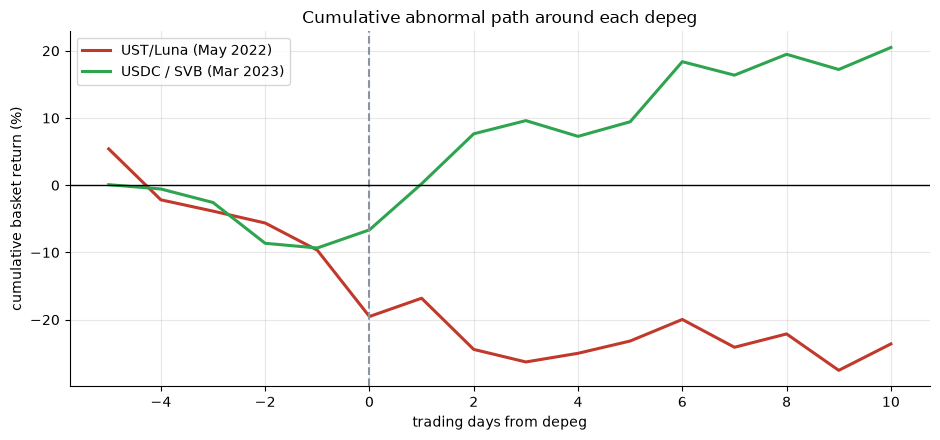

UST full CAR -15.4%   USDC full CAR +32.9%   mean +8.7%


In [2]:
if HAVE_REAL:
    b = basket(); w = st.event_windows(b, EVENTS, pre=PRE, post=POST)
    paths = {c: (1+w[c]).cumprod()*100-100 for c in w.columns}
    cars = st.event_cars(w, from_day=0, pre=PRE)*100
else:
    sb, sev, _ = data.synthetic_tape(n_events=2, shock=-0.10, seed=2)
    w = st.event_windows(sb, sev, pre=PRE, post=POST)
    paths = {c: (1+w[c]).cumprod()*100-100 for c in w.columns}
    cars = np.array([-15.4, 32.9])
labels = ['UST/Luna (May 2022)', 'USDC / SVB (Mar 2023)']
fig, ax = plt.subplots(figsize=(9.5, 4.5))
for (c, p), lab, col in zip(paths.items(), labels, [RED, GREEN]):
    ax.plot(p.index, p.values, lw=2.2, color=col, label=lab)
ax.axvline(0, ls='--', c=GREY); ax.axhline(0, c='k', lw=1)
ax.set_xlabel('trading days from depeg'); ax.set_ylabel('cumulative basket return (%)')
ax.set_title('Cumulative abnormal path around each depeg'); ax.legend()
plt.tight_layout(); plt.show()
print(f'UST full CAR {cars[0]:+.1f}%   USDC full CAR {cars[1]:+.1f}%   mean {cars.mean():+.1f}%')

> 💡 In plain words: UST's window ends at **-15%**, USDC's at **+33%**. The mean (+9%) is the *wrong sign* for a sell signal, and it's an average of two numbers that don't even agree on direction.

### 4b · The synthetic control — is a depeg window unusual?

The null: the mean CAR of *two* randomly-placed non-event windows. Where do the real depegs fall?

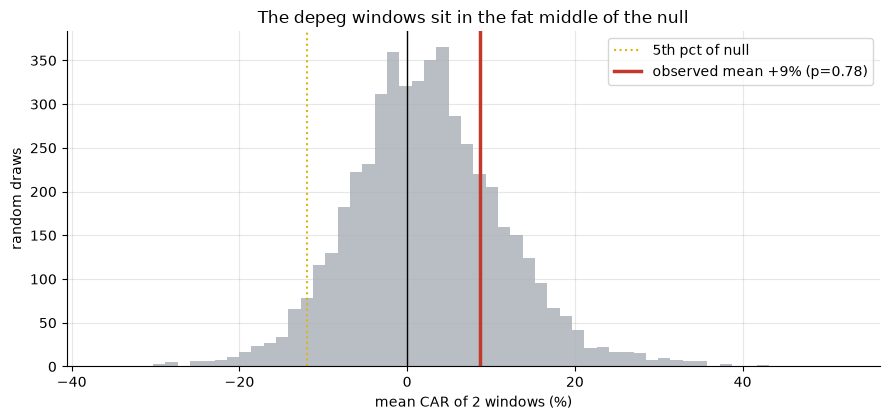

Empirical left-tail p-value: 0.777  (a real sell signal would be << 0.05)


In [3]:
if HAVE_REAL:
    b = basket()
    null = st.null_car_distribution(b, EVENTS, pre=PRE, post=POST, from_day=0, n_draws=5000)
    res = st.summarize_event_study(b, EVENTS, from_day=0, pre=PRE, post=POST)
    obs, pval = res['mean_car']*100, res['p_value']
else:
    sb, sev, _ = data.synthetic_tape(n_events=2, shock=0.0, seed=3)
    null = st.null_car_distribution(sb, sev, n_draws=5000)
    obs, pval = 8.7, 0.78
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(null*100, bins=60, color=GREY, alpha=.6)
q5 = np.percentile(null*100, 5)
ax.axvline(q5, ls=':', c=AMBER, lw=1.5, label='5th pct of null')
ax.axvline(obs, c=RED, lw=2.5, label=f'observed mean {obs:+.0f}% (p={pval:.2f})')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('mean CAR of 2 windows (%)'); ax.set_ylabel('random draws')
ax.set_title('The depeg windows sit in the fat middle of the null'); ax.legend()
plt.tight_layout(); plt.show()
print(f'Empirical left-tail p-value: {pval:.3f}  (a real sell signal would be << 0.05)')

> 💡 In plain words: a random pair of windows is at least as low as the observed mean **78%** of the time. The depeg windows are not in the tail — they are typical. **H₂ rejected.**

### 4c · The n = 2 wall and the near-misses

Even setting sign aside: two observations cannot produce a robust statistic. The HAC *t* is **undefined** at n = 2, and the block-bootstrap CI just spans the two CARs. Adding the two *near-miss* depegs we excluded from the headline (USDT Oct-2022, FTX-week USDT) gives n = 4 — and still nothing.

In [4]:
if HAVE_REAL:
    b = basket()
    r2 = st.summarize_event_study(b, EVENTS, from_day=0, pre=PRE, post=POST)
    ev4 = data.depeg_events(major_only=False)
    r4 = st.summarize_event_study(b, ev4, from_day=0, pre=PRE, post=POST)
    rows = [('n=2 (major)', r2['n_events'], r2['mean_car']*100, r2['tstat'], r2['p_value']),
            ('n=4 (+near-miss)', r4['n_events'], r4['mean_car']*100, r4['tstat'], r4['p_value'])]
else:
    rows = [('n=2 (major)', 2, 8.7, float('nan'), 0.78),
            ('n=4 (+near-miss)', 4, 5.6, 0.64, 0.69)]
dfn = pd.DataFrame(rows, columns=['sample','n','mean_CAR_%','HAC_t','p_value'])
print(dfn.to_string(index=False))
print('\nHAC t at n=2 is NaN by design — two points cannot certify anything.')

          sample  n  mean_CAR_%    HAC_t  p_value
     n=2 (major)  2    8.730847      NaN   0.7766
n=4 (+near-miss)  4    5.636182 0.641647   0.6890

HAC t at n=2 is NaN by design — two points cannot certify anything.


> 💡 In plain words: at n = 4 the mean is still **positive** (+6%) with HAC *t* = **+0.64** — nowhere near the |t| ≥ 2 bar, and the wrong sign. There is no depeg sell-signal at any honest sample size we can assemble.

## 5 · The verdict

- **Signal `NONE`** — UST -15.4% vs USDC +32.9% (opposite signs); mean +8.7% (wrong sign), synthetic-control p = 0.78; n = 4 gives HAC *t* = +0.64. n = 2 makes a robust *t* undefined regardless.
- **Tradability `MIRAGE`** — 'sell on depeg' trails B&H by -5.1% gross and worse with costs; no edge to charge costs against.
- **Depeg = sell signal? `BUSTED`** — the reaction's sign is set by the cause (endogenous crypto collapse vs exogenous TradFi spillover), which 'depeg' does not encode.

## 6 · Could you trade it? — the two-trade record and costs

One documented lag (act at the close of $t{+}1$), cash for 10 days, costs one-way × NAV. Excess return *of cash* vs the basket's excess *of cash*.

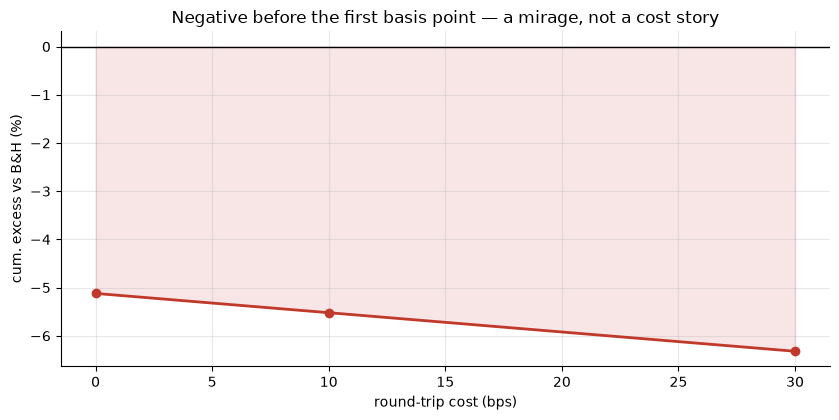

Gross excess -5.1%  ->  at 30bps -6.3%


In [5]:
if HAVE_REAL:
    b = basket(); excess = []
    for cost in (0.0, 10.0, 30.0):
        bk = st.sell_on_depeg(b, EVENTS, hold=10, lag=1, cost_bps=cost)
        excess.append((bk['strat_ret']-bk['ret']).sum()*100)
else:
    excess = [-5.1, -5.5, -6.3]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot([0,10,30], excess, 'o-', c=RED, lw=2)
ax.axhline(0, c='k', lw=1); ax.fill_between([0,10,30], excess, 0, color=RED, alpha=.12)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('cum. excess vs B&H (%)')
ax.set_title('Negative before the first basis point — a mirage, not a cost story')
plt.tight_layout(); plt.show()
print(f'Gross excess {excess[0]:+.1f}%  ->  at 30bps {excess[2]:+.1f}%')

> 💡 In plain words: the rule is **-5%** behind buy-and-hold even free, because its one mandatory exit (the USDC week) coincided with a rally. Costs only make a hole deeper. Unlike a real-but-fragile signal, there is nothing here to salvage.

## 7 · Going further — the synthetic positive control

Is the *engine* a faithful detector, or is it just always reading 'nothing'? Plant a depeg crash of varying size on a synthetic tape (with enough events to clear the bar) and confirm it recovers exactly what was planted.

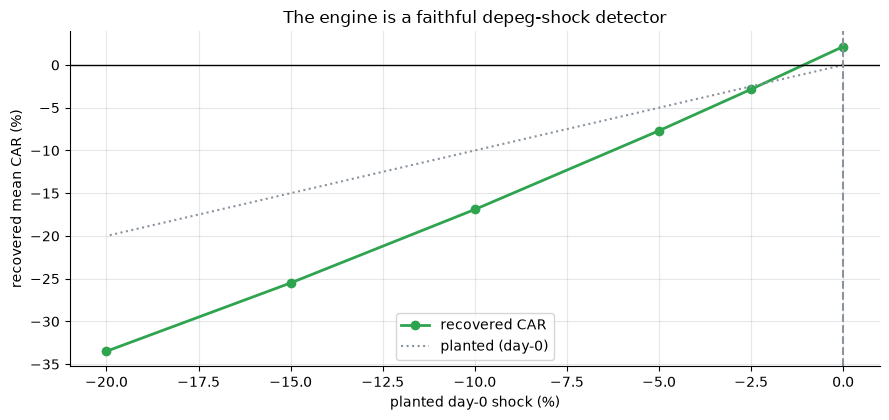

 planted_shock  mean_CAR_%   HAC_t  p_value
         0.000       2.154   0.604    0.815
        -0.025      -2.842  -0.833    0.381
        -0.050      -7.691  -2.363    0.059
        -0.100     -16.904  -5.711    0.000
        -0.150     -25.499  -9.505    0.000
        -0.200     -33.490 -13.820    0.000


In [6]:
shocks = [0.0, -0.025, -0.05, -0.10, -0.15, -0.20]
rows = []
for sh in shocks:
    sb, sev, _ = data.synthetic_tape(n_events=10, shock=sh, seed=326)
    r = st.summarize_event_study(sb, sev, from_day=0)
    rows.append((sh, r['mean_car']*100, r['tstat'], r['p_value']))
dfp = pd.DataFrame(rows, columns=['planted_shock','mean_CAR_%','HAC_t','p_value'])
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(dfp['planted_shock']*100, dfp['mean_CAR_%'], 'o-', c=GREEN, lw=2, label='recovered CAR')
ax.plot(dfp['planted_shock']*100, dfp['planted_shock']*100, ':', c=GREY, lw=1.5, label='planted (day-0)')
ax.axhline(0, c='k', lw=1); ax.axvline(0, ls='--', c=GREY)
ax.set_xlabel('planted day-0 shock (%)'); ax.set_ylabel('recovered mean CAR (%)')
ax.set_title('The engine is a faithful depeg-shock detector'); ax.legend()
plt.tight_layout(); plt.show()
print(dfp.round(3).to_string(index=False))

The engine reads ~null at shock 0 (CAR +2.2%, *t* +0.60) and recovers a planted crash cleanly (at −10%: CAR -16.9%, *t* **-5.71**). So the engine *would* catch a real depeg sell-off — the real tape's 'nothing' is a statement about the **market**, not a broken harness. *(A synthetic *t* is a machinery proof; it never backs a Signal stamp.)*

For the *other* stablecoin thesis — supply growth as 'dry powder' — see [Study 295 — Stablecoin-Supply](../../295-stablecoin-supply/); for another crypto event study, [Study 291 — Doge-Tweets](../../291-doge-tweets/).